In [143]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import root_mean_squared_error, r2_score

%matplotlib inline

In [144]:
df_2020 = pd.read_csv('data/df_2020_mit_labels.csv')
df_2021 = pd.read_csv('data/df_2021_mit_labels.csv')

In [145]:
df_2020 = df_2020.drop(columns=['system:index', 'image_count', '.geo'])
df_2020 = df_2020.fillna(df_2020.mean())

df_2021 = df_2021.drop(columns=['system:index', 'image_count', '.geo'])
df_2021 = df_2021.fillna(df_2021.mean())

In [146]:
# B1, B9, B10

In [147]:
mean_median_cols = [col for col in df_2020.columns if ('_median' in col)]
excluded_bands = [col for col in mean_median_cols if not ('B1_' in col or 'B9_' in col or 'B8A' in col or 'B10_' in col)]

all_target_cols = [
    'bare_sparse_vegetation', 'built_up', 'cropland', 'grassland',
    'herbaceous_wetland', 'mangroves', 'moss_lichen', 'shrubland',
    'snow_ice', 'tree_cover', 'water'
]

selected_labels = [
    'tree_cover', 'built_up',
    'grassland', 'cropland',
    # 'bare_sparse_vegetation', 'water'
]

sel_col = excluded_bands + all_target_cols
df_2020 = df_2020[sel_col]
df_2021 = df_2021[sel_col]

In [148]:
df_2020.columns

Index(['B2_median', 'B3_median', 'B4_median', 'B5_median', 'B6_median',
       'B11_median', 'B12_median', 'B7_median', 'B8_median',
       'bare_sparse_vegetation', 'built_up', 'cropland', 'grassland',
       'herbaceous_wetland', 'mangroves', 'moss_lichen', 'shrubland',
       'snow_ice', 'tree_cover', 'water'],
      dtype='str')

In [149]:
"""feature engineering
NDVI = (B8 - B4) / (B8 + B4)
NDBI = (B11 - B8) / (B11 + B8)
NDWI = (B3 - B8) / (B3 + B8)
"""

df_2020['NDVI'] = (df_2020['B8_median'] - df_2020['B4_median']) / (df_2020['B8_median'] + df_2020['B4_median'])
df_2020['NDBI'] = (df_2020['B11_median'] - df_2020['B8_median']) / (df_2020['B11_median'] + df_2020['B8_median'])
# df_2020['NDWI'] = (df_2020['B3_median'] - df_2020['B8_median']) / (df_2020['B3_median'] + df_2020['B8_median'])

df_2021['NDVI'] = (df_2021['B8_median'] - df_2021['B4_median']) / (df_2021['B8_median'] + df_2021['B4_median'])
df_2021['NDBI'] = (df_2021['B11_median'] - df_2021['B8_median']) / (df_2021['B11_median'] + df_2021['B8_median'])
# df_2021['NDWI'] = (df_2021['B3_median'] - df_2021['B8_median']) / (df_2021['B3_median'] + df_2021['B8_median'])

In [150]:
X_train = df_2020.drop(columns=all_target_cols)
# X_train = df_2020[['B3_median', 'B8_median', 'B5_median', 'B6_median', 'B4_median', 'B11_median',  'NDVI']]
y_train = df_2020[selected_labels]

X_test = df_2021.drop(columns=all_target_cols)
# X_test = df_2021[['B3_median', 'B8_median', 'B5_median', 'B6_median', 'B4_median', 'B11_median',  'NDVI']]
y_test = df_2021[selected_labels]

In [151]:
X_train.columns

Index(['B2_median', 'B3_median', 'B4_median', 'B5_median', 'B6_median',
       'B11_median', 'B12_median', 'B7_median', 'B8_median', 'NDVI', 'NDBI'],
      dtype='str')

In [152]:
def evaluate_regression_model(model_name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_rmse = root_mean_squared_error(y_train, y_train_pred)
    train_r2 = r2_score(y_train, y_train_pred)

    test_rmse = root_mean_squared_error(y_test, y_test_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    print(f"--- {model_name} ---")
    print(f"Train R2: {train_r2:.4f} | Test R2: {test_r2:.4f}")
    print(f"Train RMSE: {train_rmse:.4f} | Test RMSE: {test_rmse:.4f}\n")

    return {
        'Model': model_name,
        'Train RMSE': train_rmse,
        'Test RMSE': test_rmse,
        'Train R2': train_r2,
        'Test R2': test_r2
    }

In [153]:
from sklearn.multioutput import MultiOutputRegressor
from sklearn.svm import SVR

models = {
    "Linear Regression": Pipeline([("scaler", StandardScaler()), ("lr", LinearRegression())]),
    "Ridge Regression": Pipeline([("scaler", StandardScaler()), ("ridge", Ridge(alpha=1.0))]),
    "Lasso Regression": Pipeline([("scaler", StandardScaler()), ("lasso", Lasso(alpha=0.1, max_iter=10000))]),
    # "SVR": Pipeline([
    #     ("scaler", StandardScaler()),
    #     ("svr", MultiOutputRegressor(SVR(kernel='rbf', C=100, epsilon=0.1)))
    # ]),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10),
    "XGBoost": MultiOutputRegressor(XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42))
}

results = []
for name, model in models.items():
    res = evaluate_regression_model(name, model, X_train, X_test, y_train, y_test)
    results.append(res)


--- Linear Regression ---
Train R2: 0.6403 | Test R2: 0.4880
Train RMSE: 0.1681 | Test RMSE: 0.2119

--- Ridge Regression ---
Train R2: 0.6403 | Test R2: 0.4876
Train RMSE: 0.1681 | Test RMSE: 0.2120

--- Lasso Regression ---
Train R2: 0.3148 | Test R2: 0.2889
Train RMSE: 0.2345 | Test RMSE: 0.2460

--- Random Forest ---
Train R2: 0.8661 | Test R2: 0.4290
Train RMSE: 0.1014 | Test RMSE: 0.2194

--- XGBoost ---
Train R2: 0.8987 | Test R2: 0.4405
Train RMSE: 0.0896 | Test RMSE: 0.2163



In [154]:
summary_df = pd.DataFrame(results).sort_values(by='Test RMSE', ascending=True)
display(summary_df)

,Model,Train RMSE,Test RMSE,Train R2,Test R2
0,Linear Regression,0.168149,0.211886,0.640256,0.488033
1,Ridge Regression,0.168150,0.211956,0.640251,0.487577
4,XGBoost,0.089631,0.216345,0.898718,0.440454
3,Random Forest,0.101374,0.219388,0.866138,0.428982
2,Lasso Regression,0.234481,0.246019,0.314810,0.288877


In [155]:
selected_labels = [
    'tree_cover', 'built_up', 'grassland', 'cropland',
    'bare_sparse_vegetation', 'water'
]

pd.DataFrame({'mean': df_2020[selected_labels].mean(), 'std': df_2020[selected_labels].std()})

,mean,std
tree_cover,0.380674,0.364216
built_up,0.353596,0.355716
grassland,0.123147,0.213471
cropland,0.108197,0.257449
bare_sparse_vegetation,0.023480,0.071798
water,0.010726,0.074863


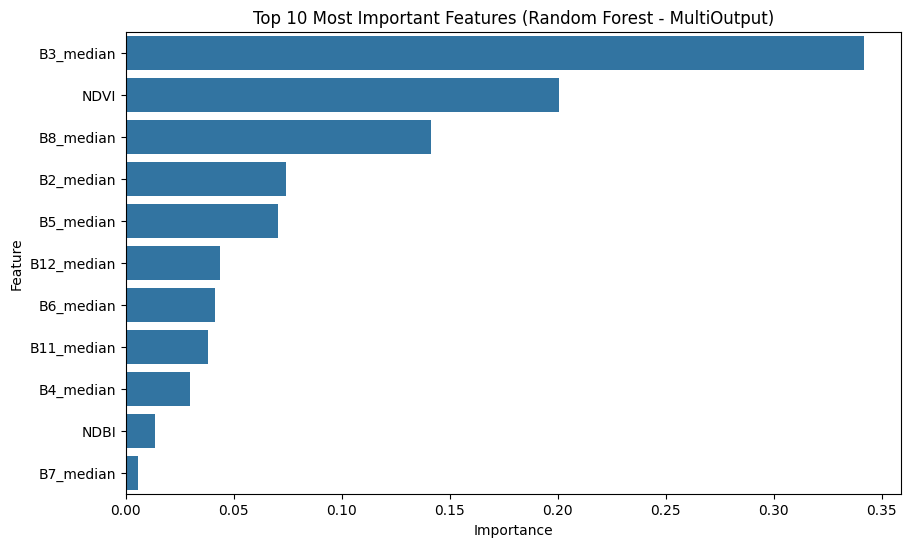

       Feature  Importance
1    B3_median    0.341680
9         NDVI    0.200708
8    B8_median    0.141453
0    B2_median    0.073945
3    B5_median    0.070406
6   B12_median    0.043535
4    B6_median    0.041397
5   B11_median    0.038077
2    B4_median    0.029720
10        NDBI    0.013437
7    B7_median    0.005640


In [156]:
feature_names = X_train.columns
importances = models['Random Forest'].feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Top 10 Most Important Features (Random Forest - MultiOutput)')
plt.show()

print(feature_importance_df)

,True_Dominant_Class,Pred_Dominant_Class,Match
0,tree_cover,cropland,False
1,tree_cover,tree_cover,True
2,grassland,cropland,False
3,tree_cover,tree_cover,True
4,tree_cover,tree_cover,True


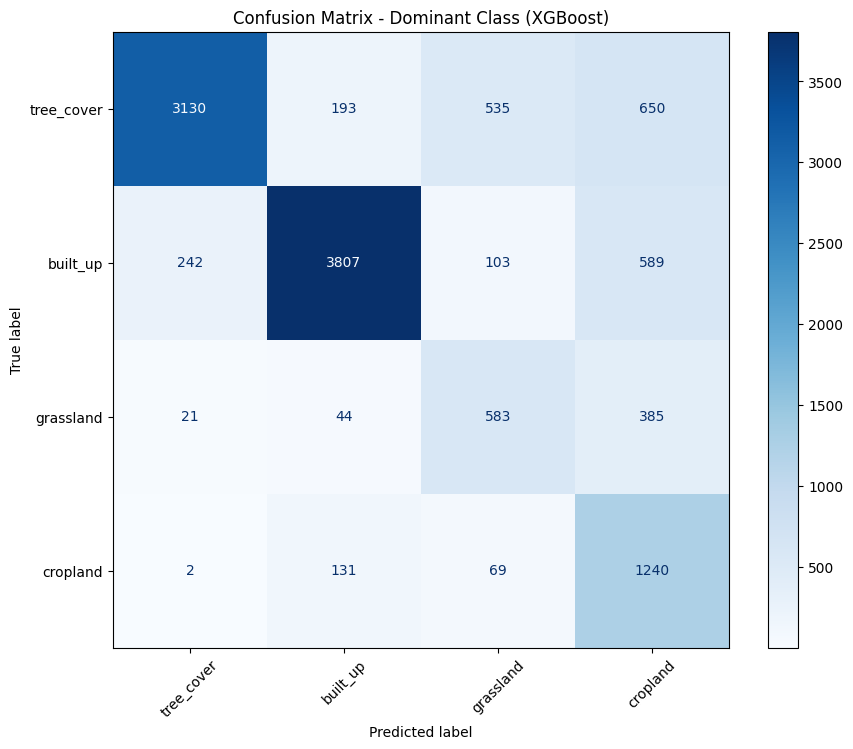

Overall Dominant Class Accuracy: 0.7472


In [157]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Use the labels actually used during training (4 labels in your current code)
current_labels = [
    'tree_cover', 'built_up',
    'grassland', 'cropland'
]

best_model_name = "XGBoost"
y_pred_array = models[best_model_name].predict(X_test)

# 2. Create DataFrame with the matching 4 columns
y_pred_df = pd.DataFrame(y_pred_array, columns=current_labels)

# 3. Get dominant classes
true_dominant = y_test[current_labels].idxmax(axis=1).reset_index(drop=True)
pred_dominant = y_pred_df.idxmax(axis=1)

# 4. Build comparison table
comparison_df = pd.DataFrame({
    'True_Dominant_Class': true_dominant,
    'Pred_Dominant_Class': pred_dominant
})
comparison_df['Match'] = comparison_df['True_Dominant_Class'] == comparison_df['Pred_Dominant_Class']

# 5. Output results
display(comparison_df.head(5))

# 6. Generate Confusion Matrix
cm = confusion_matrix(true_dominant, pred_dominant, labels=current_labels)
plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=current_labels)
disp.plot(cmap='Blues', xticks_rotation=45, ax=plt.gca())
plt.title(f'Confusion Matrix - Dominant Class ({best_model_name})')
plt.show()

accuracy = comparison_df['Match'].mean()
print(f"Overall Dominant Class Accuracy: {accuracy:.4f}")